In [1]:
# Importing the necessary libraries
import torch
from torch import optim, utils, tensor, nn

import matplotlib.pyplot as plt
from getdist import plots, MCSamples

from Network import Generator, Discriminator
from Signal_Generator import *

from tqdm import tqdm

# Setting the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Defining the hyperparameters
datasize = 16000
num_sources = 2
noise_amplitude = 0
freq_range = (1e-4, 1e-1)
total_time = 1000

num_latent_variables = 20
learning_rate = 1e-5
weight_clip = 0.1

d_loss_threshold = -0.1
g_loss_threshold = -0.3
threshold_adjustment = 0.025
max_steps = 300

num_epochs = 500

In [3]:
# Defining the distribution for amplitude and angular frequency
def amp_distribution(size):
    """
    Amplitude distribution using uniform distribution.
    """
    return np.random.uniform(4, 16, size=size)

def omega_distribution(size):
    """
    Angular frequency distribution using uniform distribution.
    """
    return np.random.uniform(2 * np.pi * 1e-4, 2 * np.pi * 1e-1, size=size)


In [4]:
dataset = torch.load('dataset.pt')

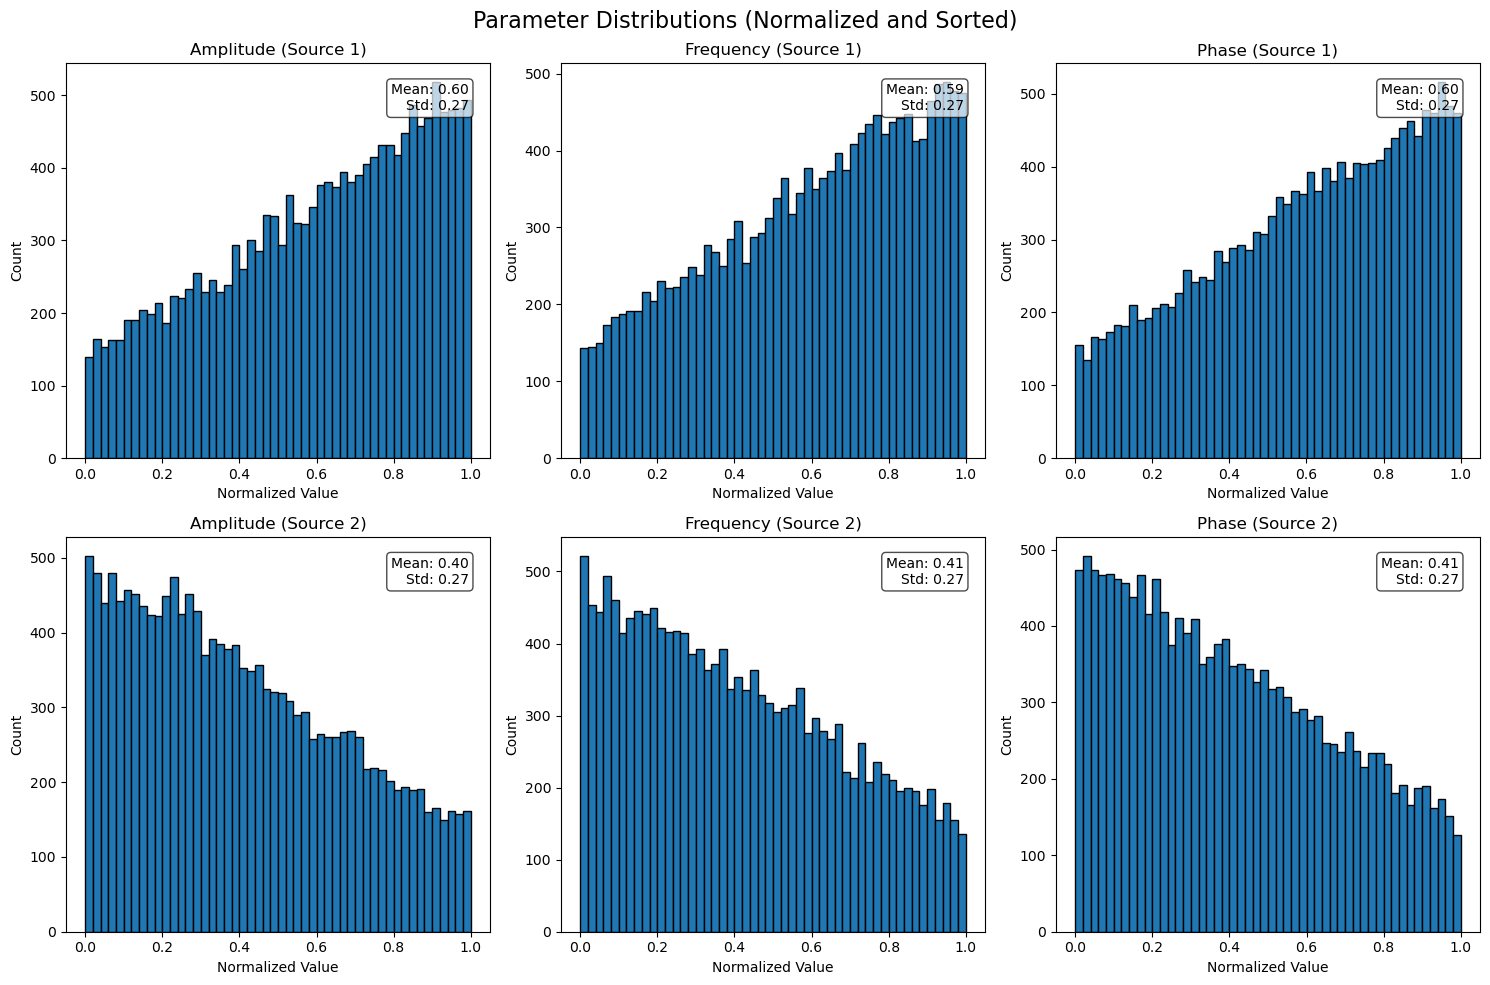

In [5]:
# 加载数据集
dataset = torch.load('dataset.pt')

# 提取参数
params_list = [item[1].cpu().numpy() for item in dataset]
params_array = np.array(params_list)

# 设置图表
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Parameter Distributions (Normalized and Sorted)', fontsize=16)

param_names = ['Amplitude (Source 1)', 'Frequency (Source 1)', 'Phase (Source 1)',
               'Amplitude (Source 2)', 'Frequency (Source 2)', 'Phase (Source 2)']

for i, (ax, name) in enumerate(zip(axs.flat, param_names)):
    # 绘制直方图
    ax.hist(params_array[:, i], bins=50, edgecolor='black')
    ax.set_title(name)
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Count')
    
    # 添加均值和标准差信息
    mean = np.mean(params_array[:, i])
    std = np.std(params_array[:, i])
    ax.text(0.95, 0.95, f'Mean: {mean:.2f}\nStd: {std:.2f}', 
            transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

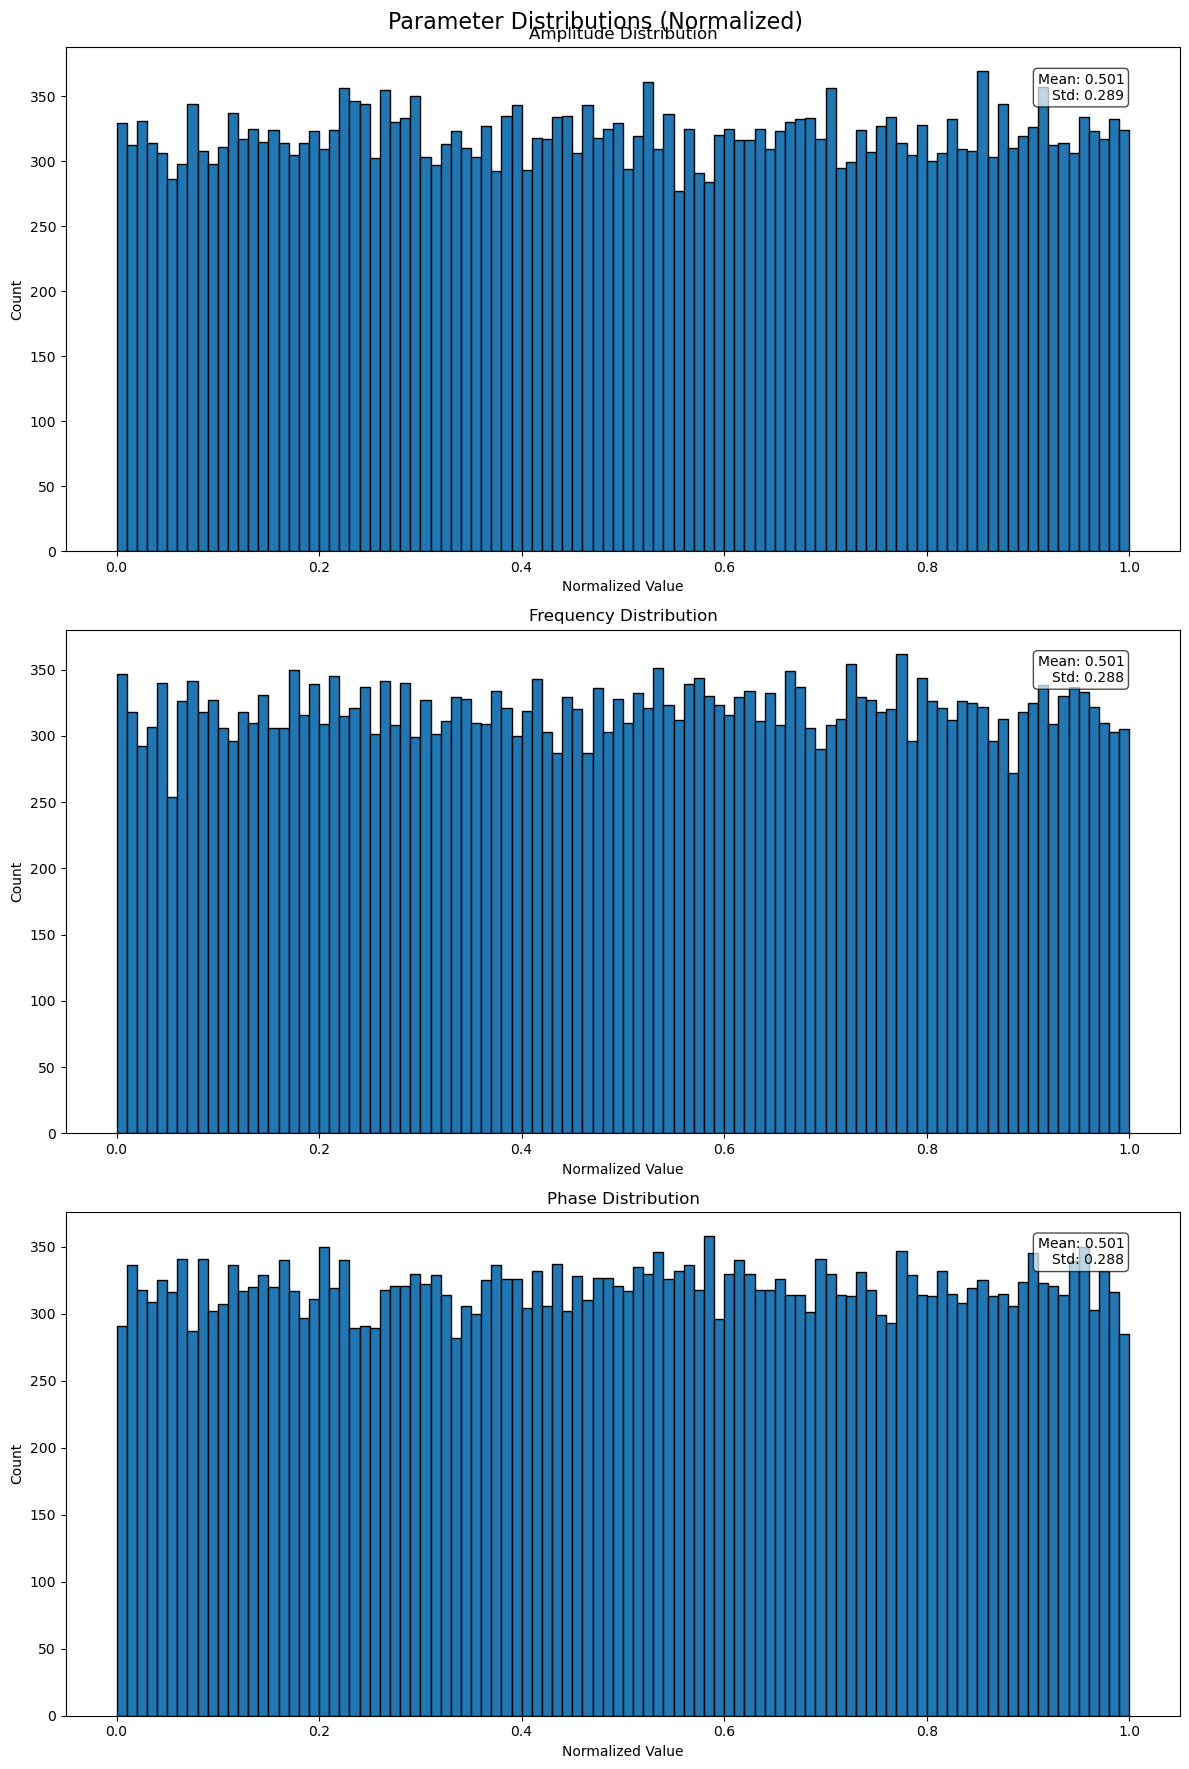

In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 加载数据集
dataset = torch.load('dataset.pt')

# 提取参数
params_list = [item[1].cpu().numpy() for item in dataset]
params_array = np.array(params_list)

# 合并两个信号源的相同参数
amplitudes = np.concatenate((params_array[:, 0], params_array[:, 3]))
frequencies = np.concatenate((params_array[:, 1], params_array[:, 4]))
phases = np.concatenate((params_array[:, 2], params_array[:, 5]))

# 设置图表
fig, axs = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle('Parameter Distributions (Normalized)', fontsize=16)

param_data = [amplitudes, frequencies, phases]
param_names = ['Amplitude', 'Frequency', 'Phase']

for ax, data, name in zip(axs, param_data, param_names):
    # 绘制直方图
    ax.hist(data, bins=100, edgecolor='black')
    ax.set_title(f'{name} Distribution')
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Count')
    
    # 添加统计信息
    mean = np.mean(data)
    std = np.std(data)
    ax.text(0.95, 0.95, f'Mean: {mean:.3f}\nStd: {std:.3f}', 
            transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

# 可选：保存图片
# plt.savefig('parameter_distributions_combined.png', dpi=300, bbox_inches='tight')

In [5]:
generator = torch.load('generator.pt')
Discriminator = torch.load('discriminator.pt')

generator.eval()

Generator(
  (init_conv): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (init_relu): LeakyReLU(negative_slope=0.2)
  (res_block_no_norm): ResBlock(
    (conv1): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (down1): Conditional_Down(
    (conv): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): LeakyReLU(negative_slope=0.2)
    (avg_pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (res_block): Conditional_ResBlock(
      (conv1): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (leaky_relu): LeakyReLU(negative_slope=0.2)
      (process1): CIN(
        (inst_norm): InstanceNorm1d(

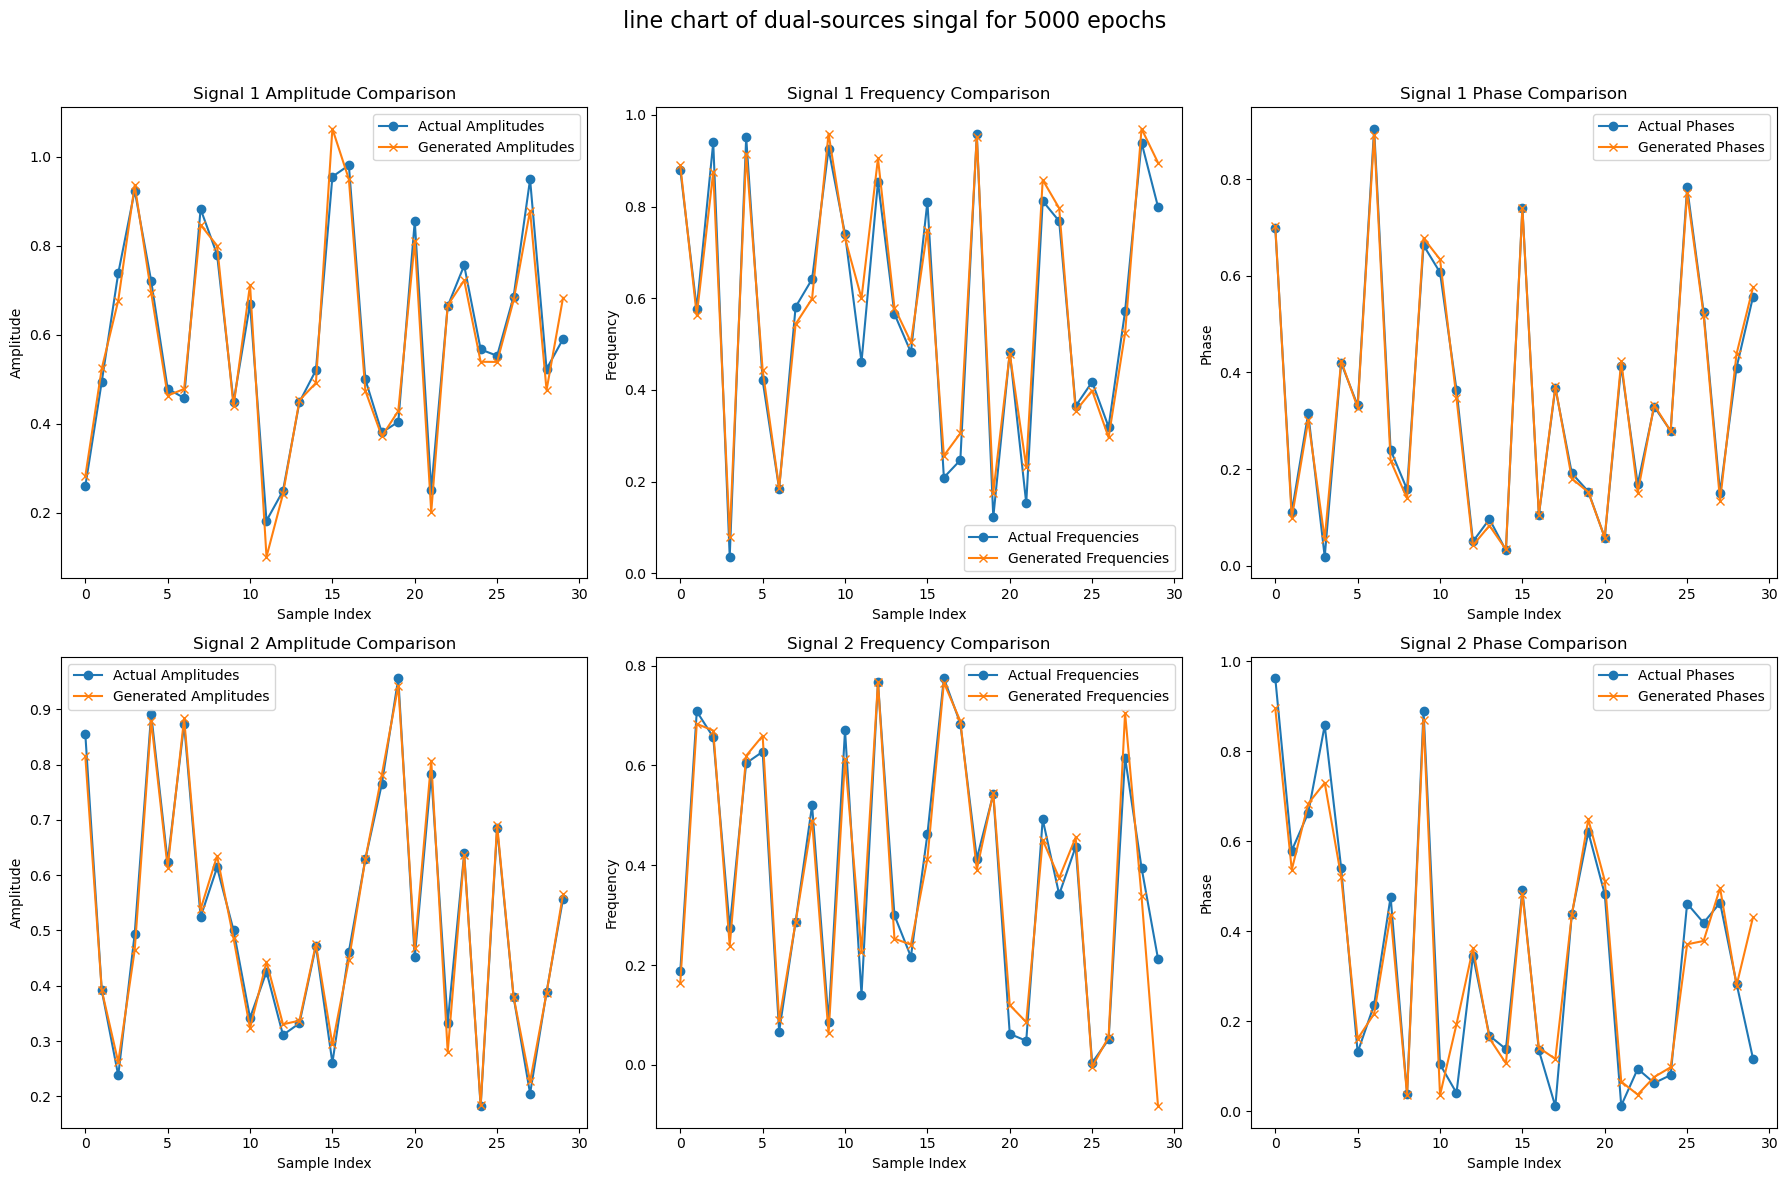

In [27]:
# Generating the parameters for line chart
params_list = []
generated_params_list = []

test_times = 30
for i in range(test_times):
    TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, freq_range=freq_range, total_time=total_time, amp_distribution_func=amp_distribution, omega_distribution_func=omega_distribution)
    test_data = TS.generating_signal()
    params = TS.printing_parameters()

    input_signal = test_data['Signal'].values
    input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()

    params_list.append(params)
    generated_params_list.append(generated_params)

actual_amplitudes = [[] for _ in range(num_sources)]
actual_frequencies = [[] for _ in range(num_sources)]
actual_phases = [[] for _ in range(num_sources)]

generated_amplitudes = [[] for _ in range(num_sources)]
generated_frequencies = [[] for _ in range(num_sources)]
generated_phases = [[] for _ in range(num_sources)]

for params in params_list:
    for i in range(num_sources):
        actual_amplitudes[i].append(params[i])
        actual_frequencies[i].append(params[num_sources + i])
        actual_phases[i].append(params[2 * num_sources + i])

for gen_params in generated_params_list:
    for i in range(num_sources):
        generated_amplitudes[i].append(gen_params[i])
        generated_frequencies[i].append(gen_params[num_sources + i])
        generated_phases[i].append(gen_params[2 * num_sources + i])

plt.figure(figsize=(18, 6 * num_sources))

for i in range(num_sources):
    plt.subplot(num_sources, 3, 3 * i + 1)
    plt.plot(range(test_times), actual_amplitudes[i], 'o-', label='Actual Amplitudes')
    plt.plot(range(test_times), generated_amplitudes[i], 'x-', label='Generated Amplitudes')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
    plt.title(f'Signal {i+1} Amplitude Comparison')
    plt.legend()

    plt.subplot(num_sources, 3, 3 * i + 2)
    plt.plot(range(test_times), actual_frequencies[i], 'o-', label='Actual Frequencies')
    plt.plot(range(test_times), generated_frequencies[i], 'x-', label='Generated Frequencies')
    plt.xlabel('Sample Index')
    plt.ylabel('Frequency')
    plt.title(f'Signal {i+1} Frequency Comparison')
    plt.legend()

    plt.subplot(num_sources, 3, 3 * i + 3)
    plt.plot(range(test_times), actual_phases[i], 'o-', label='Actual Phases')
    plt.plot(range(test_times), generated_phases[i], 'x-', label='Generated Phases')
    plt.xlabel('Sample Index')
    plt.ylabel('Phase')
    plt.title(f'Signal {i+1} Phase Comparison')
    plt.legend()

plt.suptitle(f'line chart of dual-sources singal for 5000 epochs', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])


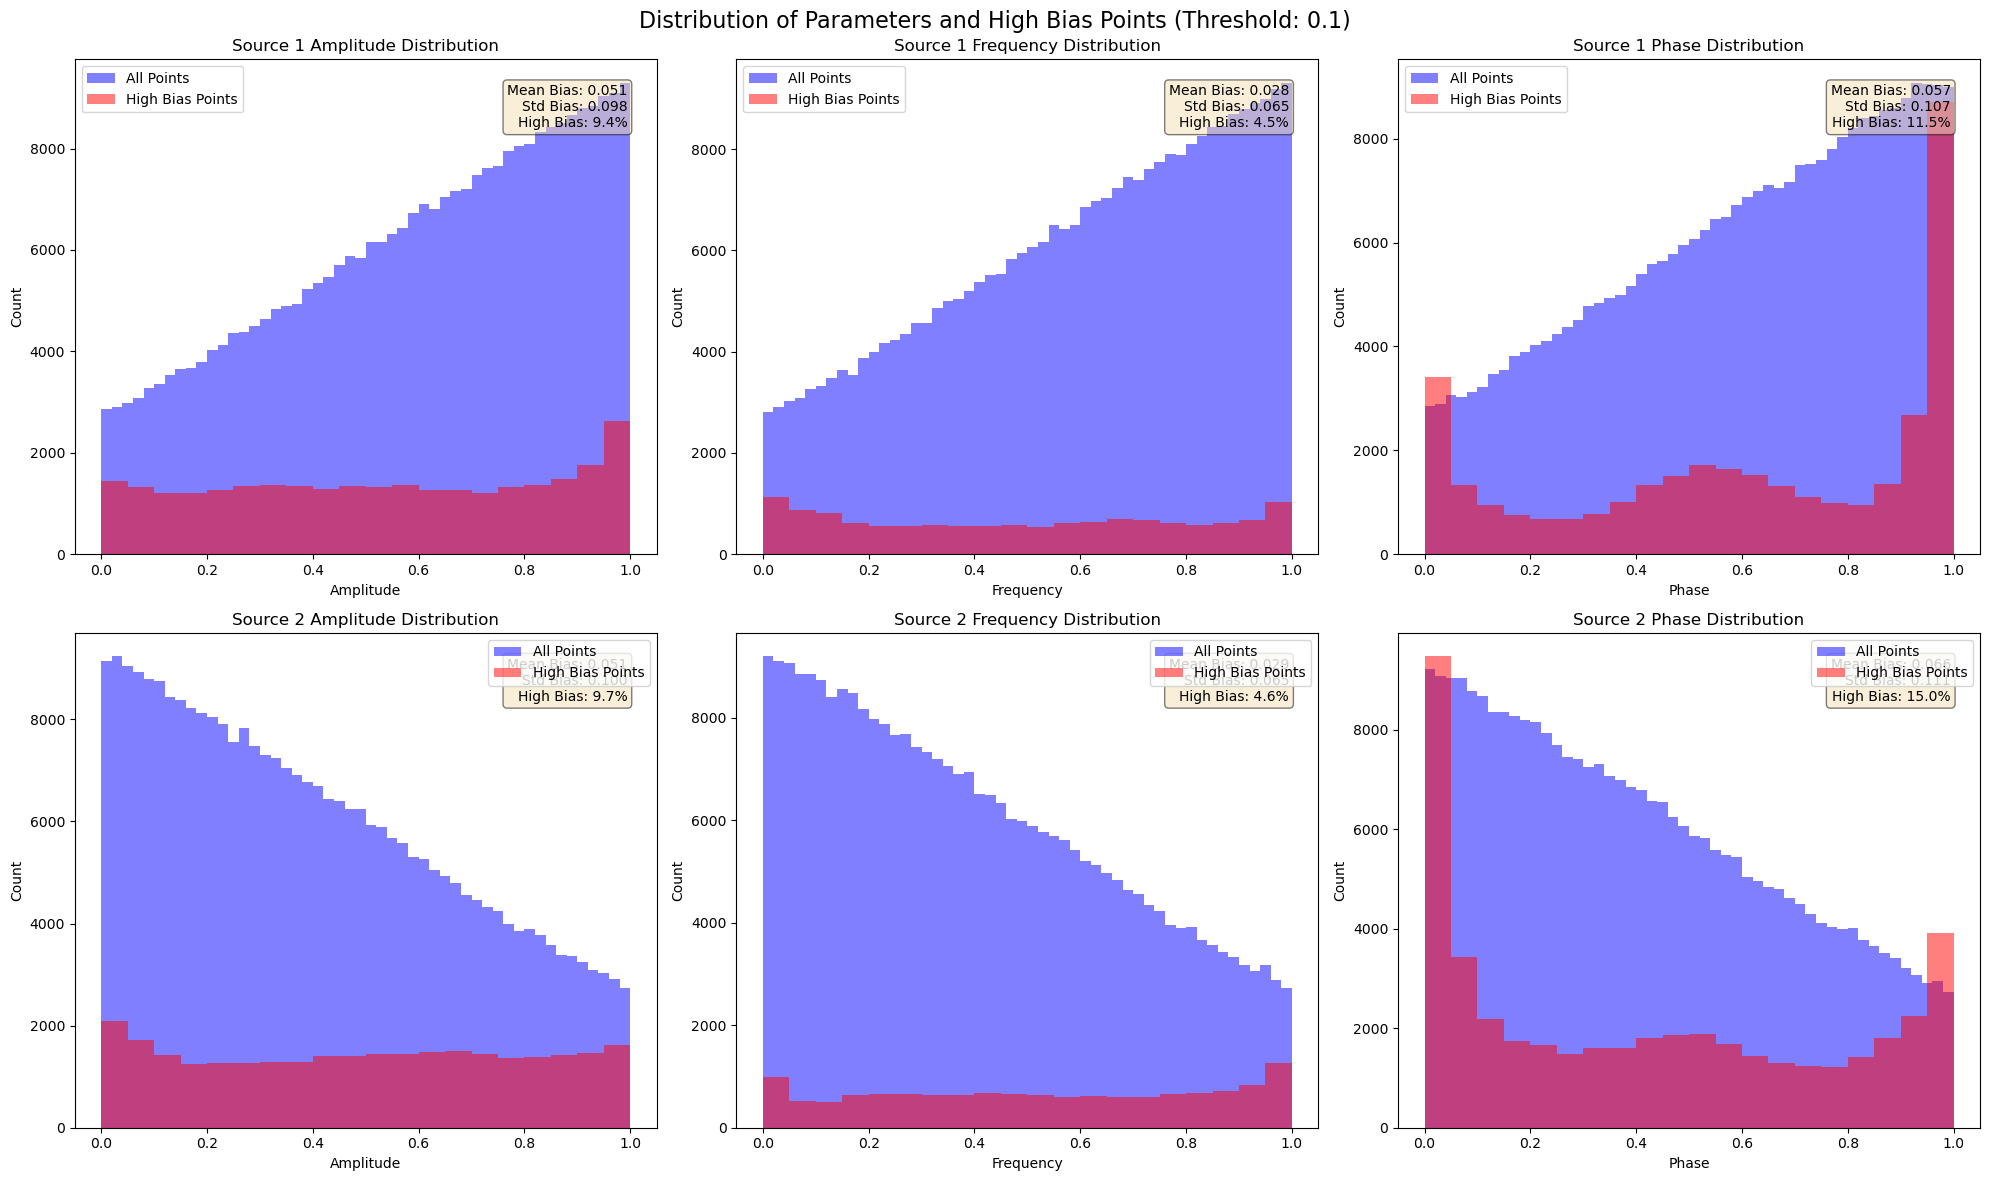

In [17]:
params_list = []
generated_params_list = []

test_times = 300000
for i in range(test_times):
    TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, freq_range=freq_range, total_time=total_time, amp_distribution_func=amp_distribution, omega_distribution_func=omega_distribution)
    test_data = TS.generating_signal()
    params = TS.printing_parameters()

    input_signal = test_data['Signal'].values
    input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()

    params_list.append(params)
    generated_params_list.append(generated_params)

def plot_high_bias_distribution(actual_params_list, generated_params_list, threshold=0.1):
    num_sources = len(actual_params_list[0]) // 3
    param_names = ['Amplitude', 'Frequency', 'Phase']
    
    fig, axs = plt.subplots(num_sources, 3, figsize=(20, 6*num_sources))
    fig.suptitle(f'Distribution of Parameters and High Bias Points (Threshold: {threshold})', fontsize=16)
    
    for i in range(num_sources):
        for j, param in enumerate(param_names):
            actual_values = [sample[i*3 + j] for sample in actual_params_list]
            generated_values = [sample[i*3 + j] for sample in generated_params_list]
            
            # 计算normalized bias
            param_range = max(actual_values) - min(actual_values)
            if param_range == 0:
                print(f"Warning: Zero range for Source {i+1}, {param}")
                continue
            biases = np.abs(np.array(actual_values) - np.array(generated_values)) / param_range
            
            # 找出高偏差的点
            high_bias_indices = biases > threshold
            high_bias_values = np.array(actual_values)[high_bias_indices]
            
            # 绘制总体分布
            axs[i, j].hist(actual_values, bins=50, alpha=0.5, color='blue', label='All Points')
            
            # 绘制高偏差点分布
            if len(high_bias_values) > 0:
                axs[i, j].hist(high_bias_values, bins=20, alpha=0.5, color='red', label='High Bias Points')
            
            axs[i, j].set_title(f'Source {i+1} {param} Distribution')
            axs[i, j].set_xlabel(param)
            axs[i, j].set_ylabel('Count')
            axs[i, j].legend()
            
            # 添加统计信息
            mean_bias = np.mean(biases)
            std_bias = np.std(biases)
            high_bias_percentage = (len(high_bias_values) / len(actual_values)) * 100
            
            stats_text = f'Mean Bias: {mean_bias:.3f}\nStd Bias: {std_bias:.3f}\nHigh Bias: {high_bias_percentage:.1f}%'
            axs[i, j].text(0.95, 0.95, stats_text, transform=axs[i, j].transAxes, 
                           verticalalignment='top', horizontalalignment='right',
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

# 使用函数
plot_high_bias_distribution(params_list, generated_params_list, threshold=0.1)

[0.7294557902399775, 0.7844857026045068, 0.8196913187913458, 0.7439497882841617, 0.24110653312047514, 0.40484428157970287]
[array([0.6844444 , 0.8021157 , 0.8168346 , 0.7891061 , 0.22938848,
       0.4037182 ], dtype=float32), array([0.6957241 , 0.80315506, 0.8280584 , 0.7807883 , 0.23169114,
       0.41421154], dtype=float32), array([0.68938744, 0.8102994 , 0.82150966, 0.7906785 , 0.22134393,
       0.41995916], dtype=float32), array([0.6945946 , 0.80772245, 0.828025  , 0.79193604, 0.22711149,
       0.41759273], dtype=float32), array([0.6963687 , 0.80649996, 0.82884777, 0.78595334, 0.22910619,
       0.41150478], dtype=float32), array([0.6932212 , 0.7999034 , 0.8301621 , 0.7861302 , 0.22839531,
       0.41127092], dtype=float32), array([0.69999075, 0.8061502 , 0.82791024, 0.7869819 , 0.22776468,
       0.41879746], dtype=float32), array([0.692683  , 0.8035451 , 0.8334955 , 0.7825688 , 0.22933626,
       0.41678354], dtype=float32), array([0.6928227 , 0.8057995 , 0.832132  , 0.7806486

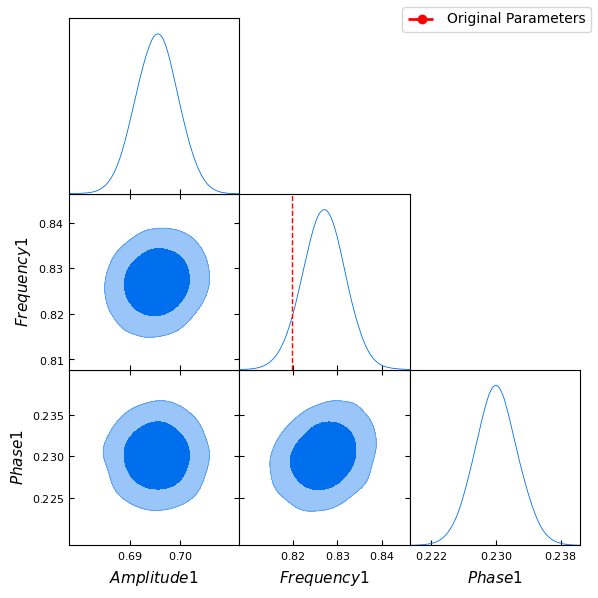

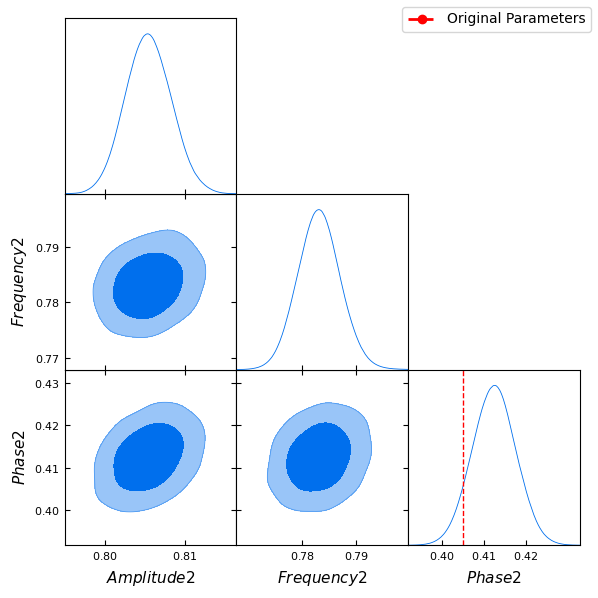

In [31]:
# Generating the parameters for triangle graph
generated_params_list = []

TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, freq_range=freq_range, 
                      total_time=total_time, amp_distribution_func=amp_distribution, omega_distribution_func=omega_distribution)
test_data = TS.generating_signal()
params = TS.printing_parameters()

input_signal = test_data['Signal'].values
input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

for i in range(10000):
    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()

    generated_params_list.append(generated_params)

print(params)
print(generated_params_list)

columns = []
for i in range(num_sources):
    columns.extend([f'Amplitude{i+1}', f'Frequency{i+1}', f'Phase{i+1}'])

generated_params_df = pd.DataFrame(generated_params_list, columns=columns)

for i in range(num_sources):
    amplitude_idx = i
    frequency_idx = num_sources + i
    phase_idx = 2 * num_sources + i
    param_slice = [params[amplitude_idx], params[frequency_idx], params[phase_idx]]
    
    names = [f"A{i+1}", f"omega{i+1}", f"theta{i+1}"]
    labels = [f"Amplitude{i+1}", f"Frequency{i+1}", f"Phase{i+1}"]

    generated_params_samples = MCSamples(samples=generated_params_df.iloc[:, [amplitude_idx, frequency_idx, phase_idx]].values, names=names, labels=labels, settings={'ignore_rows': 1000})
    generated_params_samples.updateSettings({'fine_bins_2D': 1048})

    g = plots.get_subplot_plotter()

    g.triangle_plot([generated_params_samples], filled=True)

    axes = g.subplots

    for j in range(len(names)):
        for k in range(j + 1, len(names)):
            ax = axes[k, j]
            if ax is not None:
                ax.scatter(param_slice[j], param_slice[k], color='red', marker='o', s=50)

    for j in range(len(names)):
        ax = axes[j, j]
        if ax is not None:
            ax.axvline(param_slice[j], linestyle='--', color='red', lw=1)

    handles = [plt.Line2D([0], [0], color='red', lw=2, linestyle='--', marker='o')]
    labels = ['Original Parameters']
    g.fig.legend(handles, labels, loc='upper right')